# Recap - The Cars Dataset(Arabalar Veri Kümesi)

In [1]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 The Cars dataset (Arabalar Veri Kümesi)

👇 Aşağıdaki kodu çalıştırarak [***ML_Cars_Recap_dataset.csv dataset***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) dosyasını içe aktarın 

In [2]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv(aws_url)
cars.head()


# Not: CSV dosyalarını çevrim içi olarak saklamak yaygın bir uygulamadır. Bu dosya, LeWagon’un AWS hesabında saklanmaktadır.

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [3]:
cars.shape # 205 araç x 8 feature


(205, 8)

ℹ️ Dataset’in açıklaması [burada](https://drive.google.com/file/d/1giEQ6GfDPw1exbzZlE-iN2iAVk6kiZrU/view?usp=sharing) mevcuttur.

- **aspiration** → Araçta kullanılan hava besleme tipi  
  - `std` = Standart (atmosferik)  
  - `turbo` = Turbo beslemeli  

- **enginelocation** → Motorun araç üzerindeki konumu  

- **carwidth** → Aracın genişliği  

- **curbweight** → Aracın boş ağırlığı (yakıt ve yolcu hariç)  

- **enginetype** → Araçta kullanılan motor tipi  
  - `dohc` = Çift üstten eksantrik mili (Dual Overhead Cam)  
  - `dohcv` = Çift üstten eksantrik ve supaplı motor  
  - `l` = L tipi motor  
  - `ohc` = Üstten eksantrik mili (Overhead Cam)  
  - `ohcf` = Üstten eksantrik ve F tipi supaplı motor  
  - `ohcv` = Üstten eksantrik ve supaplı motor  
  - `rotor` = Rotary (döner) motor  

- **cylindernumber** → Araçtaki silindir sayısı  

- **stroke** → Pistonun her yarım dönüşte kat ettiği mesafe (piston stroku)  

- **peakrpm** → Motorun ulaştığı maksimum devir sayısı (RPM – dakika başına devir)  

- **price** → Aracın fiyat sınıfı (pahalı / ucuz)


❓ **Soru (Bilgilendirme)** ❓ Dataset’iniz hakkında bazı temel bilgileri toplayın.

In [16]:
import pandas as pd

# =========================
# 0) Duplicate subset seçimi
# =========================
dup_subset = ["aspiration","carwidth","curbweight","enginetype",
              "cylindernumber","stroke","peakrpm","price"]

# =========================
# 1) Shape + ilk bakış
# =========================
print("Shape (satır, sütun):", cars.shape)
display(cars.head(5))

# =========================
# 2) Info (dtype + null)
# =========================
print("\nINFO:")
cars.info()

# =========================
# 3) Missing yüzdeleri
# =========================
missing_pct = (cars.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % (sıralı):")
print(missing_pct[missing_pct > 0])

# =========================
# 4) Duplicate kontrolleri
# =========================
dup_all = cars.duplicated().sum()
dup_subset_count = cars.duplicated(subset=dup_subset).sum()

print("\nDuplicate (tüm sütunlar aynı) sayısı:", dup_all)
print("Duplicate (seçtiğin subset'e göre) sayısı:", dup_subset_count)
print("Duplicate subset sütunları:", dup_subset)

# subset duplicate örneklerini göster (ilk 10)
if dup_subset_count > 0:
    print("\nSubset duplicate örnekleri (ilk 10):")
    display(cars[cars.duplicated(subset=dup_subset)].head(10))

    # Duplicate gruplarını daha anlaşılır görmek için:
    # Aynı subset değerlerine sahip tüm kayıtları (tekrarlar dahil) göster
    dup_groups = cars[cars.duplicated(subset=dup_subset, keep=False)].sort_values(dup_subset)
    print("\nSubset duplicate grupları (tekrarlar dahil, sıralı):")
    display(dup_groups.head(30))

# =========================
# 5) Unique değer sayıları
# =========================
print("\nHer sütunda unique değer sayısı:")
print(cars.nunique().sort_values())

# =========================
# 6) Sayısal özet
# =========================
num_cols = cars.select_dtypes(include="number").columns
print("\nSayısal sütunlar:", list(num_cols))
display(cars[num_cols].describe().T)

# =========================
# 7) Kategorik özet
# =========================
cat_cols = cars.select_dtypes(exclude="number").columns
print("\nKategorik sütunlar:", list(cat_cols))

for col in cat_cols:
    print(f"\n{col} value counts (ilk 10):")
    print(cars[col].value_counts(dropna=False).head(10))

# =========================
# 8) Target (price) dağılımı
# =========================
# price kategorik mi kontrol et
if "price" in cars.columns:
    if cars["price"].dtype == "object":
        print("\nTarget (price) dağılımı (%):")
        print(cars["price"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")
    else:
        print("\nTarget (price) sayısal görünüyor. Temel özet:")
        print(cars["price"].describe())


Shape (satır, sütun): (205, 8)


,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   carwidth        205 non-null    float64
 2   curbweight      205 non-null    float64
 3   enginetype      205 non-null    object 
 4   cylindernumber  205 non-null    object 
 5   stroke          205 non-null    float64
 6   peakrpm         205 non-null    float64
 7   price           205 non-null    object 
dtypes: float64(4), object(4)
memory usage: 12.9+ KB

Missing % (sıralı):
Series([], dtype: float64)

Duplicate (tüm sütunlar aynı) sayısı: 14
Duplicate (seçtiğin subset'e göre) sayısı: 14
Duplicate subset sütunları: ['aspiration', 'carwidth', 'curbweight', 'enginetype', 'cylindernumber', 'stroke', 'peakrpm', 'price']

Subset duplicate örnekleri (ilk 10):


,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
1,std,64.1,2548.0,dohc,four,2.680,5000.0,expensive
11,std,64.8,2395.0,ohc,four,2.800,5800.0,expensive
22,std,63.8,1876.0,ohc,four,3.230,5500.0,cheap
26,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap
45,std,63.6,1909.0,ohc,four,3.110,5400.0,cheap
56,std,65.7,2380.0,rotor,two,3.255,6000.0,expensive
116,turbo,68.4,3252.0,l,four,3.520,4150.0,expensive
119,turbo,63.8,2128.0,ohc,four,3.390,5500.0,cheap
120,std,63.8,1967.0,ohc,four,3.230,5500.0,cheap
121,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap



Subset duplicate grupları (tekrarlar dahil, sıralı):


,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
20,std,63.6,1909.0,ohc,four,3.110,5400.0,cheap
45,std,63.6,1909.0,ohc,four,3.110,5400.0,cheap
21,std,63.8,1876.0,ohc,four,3.230,5500.0,cheap
22,std,63.8,1876.0,ohc,four,3.230,5500.0,cheap
24,std,63.8,1967.0,ohc,four,3.230,5500.0,cheap
120,std,63.8,1967.0,ohc,four,3.230,5500.0,cheap
25,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap
26,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap
121,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap
0,std,64.1,2548.0,dohc,four,2.680,5000.0,expensive



Her sütunda unique değer sayısı:
aspiration          2
price               2
enginetype          7
cylindernumber      7
peakrpm            23
stroke             37
carwidth           43
curbweight        171
dtype: int64

Sayısal sütunlar: ['carwidth', 'curbweight', 'stroke', 'peakrpm']


,count,mean,std,min,25%,50%,75%,max
carwidth,205.0,65.887940,2.074414,60.30,64.20,65.50,66.50,72.30
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17
peakrpm,205.0,5125.121951,476.985643,4150.00,4800.00,5200.00,5500.00,6600.00



Kategorik sütunlar: ['aspiration', 'enginetype', 'cylindernumber', 'price']

aspiration value counts (ilk 10):
aspiration
std      168
turbo     37
Name: count, dtype: int64

enginetype value counts (ilk 10):
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

cylindernumber value counts (ilk 10):
cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

price value counts (ilk 10):
price
expensive    123
cheap         82
Name: count, dtype: int64

Target (price) dağılımı (%):
price
expensive    60.0%
cheap        40.0%
Name: proportion, dtype: object


# (1) 🛠 Veri hazırlama (Data preparation)

## (1.0) Önkoşullar (Pre-requisites)

❓ **Soru (Olası anormallikler)** ❓ 

- Veri tipleri nedeniyle değiştirilmesi gereken sütunlar var mı?
    - Lütfen buna göre gerekli düzenlemeleri yapın.

In [24]:
cylinder_map = {
    'four': 4,
    'six': 6,
    'five': 5,
    'eight': 8,
    'two': 2,
    'three': 3,
    'twelve': 12
}

cars['cylindernumber_num'] = cars['cylindernumber'].map(cylinder_map)

if cars['cylindernumber_num'].isna().sum() == 0:
    cars['cylindernumber_num'] = cars['cylindernumber_num'].astype(int)
    
print(f"Cylinder_num: {cars['cylindernumber_num'].value_counts()}\n")
print(f"Cylinder_cat: {cars['cylindernumber'].value_counts()}")

Cylinder_num: cylindernumber_num
4     159
6      24
5      11
8       5
2       4
3       1
12      1
Name: count, dtype: int64

Cylinder_cat: cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64


## (1.1) Tekrarlananlar (Duplicates)

❓ **Soru (Tekrarlanan satırlar)** ❓

Cars dataset’inde bulunan tekrarlanan (duplicated) satır sayısını hesaplayın.

In [27]:
dup_count = cars.duplicated(subset=dup_subset).sum()
print("Duplicate count:", dup_count)

Duplicate count: 14


❓ **Soru (Yinelenenleri kaldır)** ❓ 

In [28]:
cars_clean = cars.drop_duplicates(subset= dup_subset, keep= 'first').copy()
print(f"cars Shape: {cars.shape} cars_clean Shape: {cars_clean.shape}")

cars Shape: (205, 9) cars_clean Shape: (191, 9)


## (1.2) Missing data

❓ **Soru (`NaN`)** ❓

Her bir özellik için `NaN` yüzdesi nedir?

In [29]:
missing_pct = (cars.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % (sıralı):")
print(missing_pct[missing_pct > 0])


Missing % (sıralı):
Series([], dtype: float64)


<details>
    <summary><i>Cevap</i></summary>
    
😇 Bu bir mucize ama burada eksik değer yok. Bu not defterinin bir sonraki bölümüne geçebilirsiniz :)     
</details>

## (1.3)  Özellikleri $X$ ve hedefi $y$ tanımlama (Defining the features $X$ and the target $y$)

❓ **Soru** ❓

- Bu veri kümesinin özelliklerini $X$ değişkeninde saklayın.
- Hedefi $y$ değişkeninde saklayın.

In [30]:
X = cars_clean.drop(columns='price')
y = cars_clean['price']

❓ **Soru (Hedefe hızlı bir bakış)** ❓ “Ucuz” arabaların “pahalı” arabalara oranı nedir? 

In [35]:
cars_clean['price'].value_counts(normalize=True)*100

counts = cars_clean['price'].value_counts()

ratio = counts['cheap'] / counts['expensive']

print(f"Ucuz araba sayısı: {counts['cheap']}\n")
print(f"Pahalı araba sayısı: {counts['expensive']}\n")
print(f"Ucuz arabalara pahalıların {ratio: .2f} katı.")

Ucuz araba sayısı: 74

Pahalı araba sayısı: 117

Ucuz arabalara pahalıların  0.63 katı.


## (1.4) Sayısal özelliklerin ölçeklendirilmesi (Scaling numerical features)

❓ **Soru (sayısal sütunlara hızlı bir bakış)** ❓

- Tek bir kod satırında tüm sayısal sütunların kutu grafiklerini gösterin
- Histogramları kullanarak dağılımları için de aynısını yapın

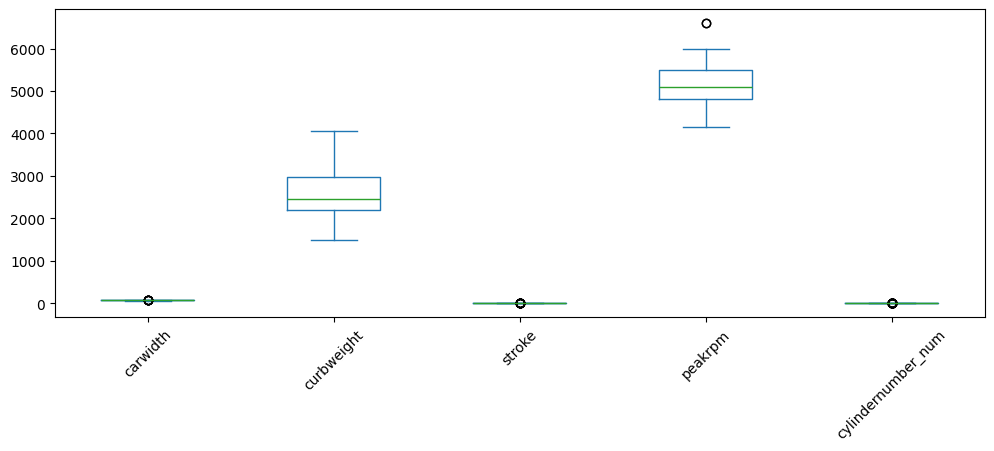

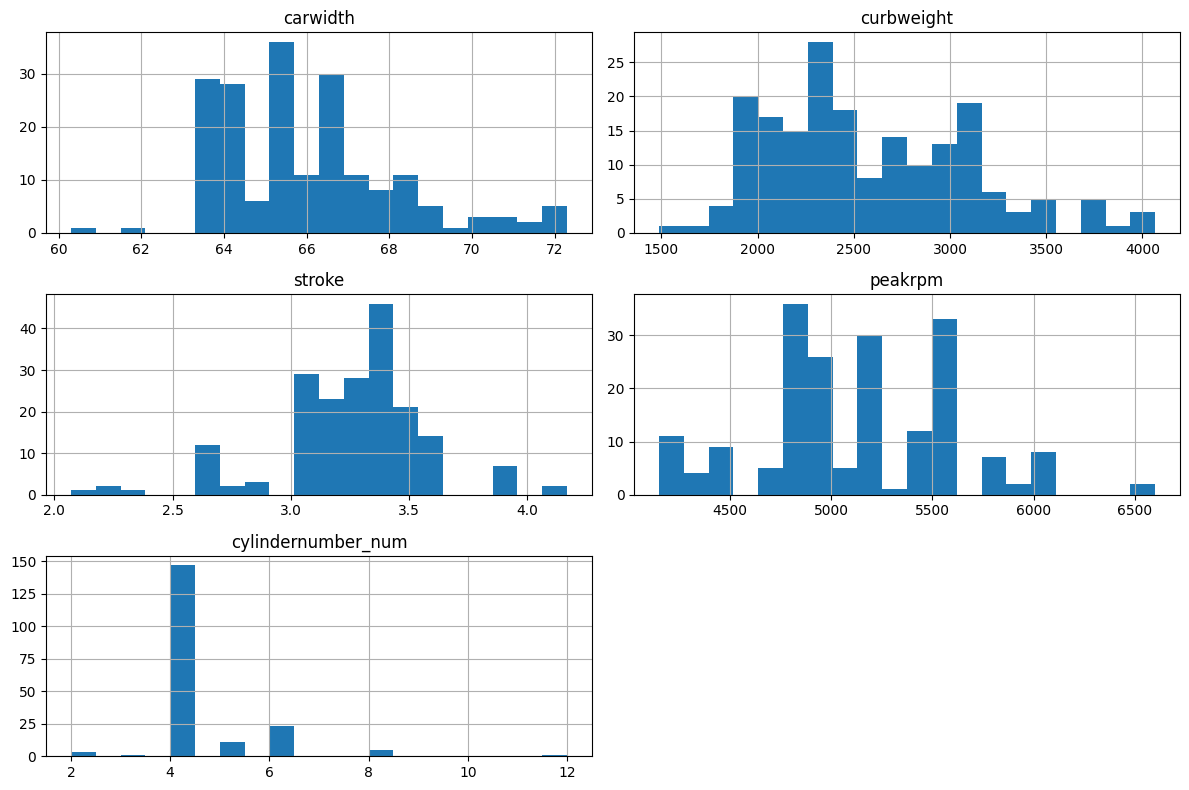

In [41]:
cars_clean.select_dtypes(include="number").plot(kind="box", figsize=(12,4), rot=45)
cars_clean.select_dtypes(include="number").hist(figsize=(12,8), bins=20)
plt.tight_layout()

❓ **Soru (Sayısal sütunlara odaklanın)** ❓

Araba veri kümesinin sayısal sütunlarını `cars_num` içinde saklayın.

In [42]:
###########################
# Manuel çözüm            # - pek akıllıca değil
###########################

# num_features = ["carwidth", "curbweight", "cylindernumber", "stroke", "peakrpm"]
# cars_num = X[num_features]

# Bu, sayısal feature’ları seçmenin bir yolu...
# Ama pek akıllıca değil...

###########################
# Zarif çözüm             # - çok daha iyi
###########################

cars_num = X.select_dtypes(exclude=['object']) # yalnızca sayısal feature’ları seçiyoruz
cars_num


,carwidth,curbweight,stroke,peakrpm,cylindernumber_num
0,64.10000,2548.0,2.68,5000.0,4
2,65.50000,2823.0,3.47,5000.0,6
3,65.88794,2337.0,3.40,5500.0,4
4,66.40000,2824.0,3.40,5500.0,5
5,66.30000,2507.0,3.40,5500.0,5
...,...,...,...,...,...
200,68.90000,2952.0,3.15,5400.0,4
201,68.80000,3049.0,3.15,5300.0,4
202,68.90000,3012.0,2.87,5500.0,6
203,68.90000,3217.0,3.40,4800.0,6


❓ **Soru (Sağlam Ölçeklendirici)** ❓

👨🏻‍🏫 Tüm sayısal özellikleri sağlam bir şekilde ölçeklendirmek, hızlı ve verimli bir ölçeklendirme yöntemidir.

In [43]:
# RobustScaler oluşturma
robust_scaler = RobustScaler().set_output(transform='pandas')

# Feature’ları ölçekleme ve saklama
cars_num_scaled = robust_scaler.fit_transform(cars_num)

# Ölçeklenmiş feature’ları gösterme
cars_num_scaled

,carwidth,curbweight,stroke,peakrpm,cylindernumber_num
0,-0.555556,0.135659,-2.033333,-0.142857,0.0
2,-0.037037,0.490956,0.600000,-0.142857,2.0
3,0.106644,-0.136951,0.366667,0.571429,0.0
4,0.296296,0.492248,0.366667,0.571429,1.0
5,0.259259,0.082687,0.366667,0.571429,1.0
...,...,...,...,...,...
200,1.222222,0.657623,-0.466667,0.428571,0.0
201,1.185185,0.782946,-0.466667,0.285714,0.0
202,1.222222,0.735142,-1.400000,0.571429,2.0
203,1.222222,1.000000,0.366667,-0.428571,2.0


## (1.5) Kategorik özelliklerin kodlanması (Encoding categorical features)

❓ **Soru (Kategorik sütunlara odaklanın)** ❓

Arabalar veri kümesinin kategorik sütunlarını `cars_categorical` içinde saklayın.

In [45]:
# Manuel çözüm --> pek akıllıca değil

categorical_features = ["aspiration", "enginetype"]
cars_categorical = X[categorical_features]

# Zarif çözüm --> çok daha iyi
#cars_categorical = X.select_dtypes(include=['object']) # yalnızca kategorik feature’ları seçiyoruz
cars_categorical

,aspiration,enginetype
0,std,dohc
2,std,ohcv
3,std,ohc
4,std,ohc
5,std,ohc
...,...,...
200,std,ohc
201,turbo,ohc
202,std,ohcv
203,turbo,ohc


❓ **Soru: Kategorik özellikleri kodlarsak, beklenen sütun sayısı kaçtır?** ❓ 9


In [52]:
print(cars_categorical['aspiration'].value_counts())
print(cars_categorical['enginetype'].value_counts())

aspiration
std      156
turbo     35
Name: count, dtype: int64
enginetype
ohc      138
ohcf      14
ohcv      13
dohc      11
l         11
rotor      3
dohcv      1
Name: count, dtype: int64


❓ **Soru (OneHotEncoder): Kategorik feature’ları encode edin** ❓

<details>
    <summary><i>İpuçları</i></summary>
    
- Bir kategorik feature binary ise bir sütunu drop edin
- Tam matrisler kullanın (Sklearn estimator’ları sparse matrix’leri anlayamaz)
- Sonuçları `encoded_features` adlı bir Pandas DataFrame içine kaydedin
    - 💡 OHE bir DataFrame’e fit edildikten sonra, yeni sütun adlarına _`get_features_names_out()`_ ile erişebilirsiniz
    
</details>

In [53]:
ohe = OneHotEncoder(
    drop='if_binary',
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = ohe.fit_transform(cars_categorical)

encoded_features = pd.DataFrame(
    encoded_array,
    columns= ohe.get_feature_names_out(cars_categorical.columns),
    index= cars_categorical.index
)

print("encoded_features shape:", encoded_features.shape) 
display(encoded_features.head())

encoded_features shape: (191, 8)


,aspiration_turbo,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.6) Önceden işlenmiş tüm özellikleri birleştirme $X_{preprocessed}$ (Concatenating all the preprocessed features together )

❓ **Soru (önceden işlenmiş tüm özellikleri bir araya getirerek)** ❓

`cars_num_scaled` ve `encoded_features` öğelerini `X_preprocessed` öğesinde birleştirin.

In [60]:
X_preprocessed = pd.concat([encoded_features, cars_num_scaled],axis= 1)
print(X_preprocessed.head())
print(X_preprocessed.columns)

   aspiration_turbo  enginetype_dohc  enginetype_dohcv  enginetype_l  \
0               0.0              1.0               0.0           0.0   
2               0.0              0.0               0.0           0.0   
3               0.0              0.0               0.0           0.0   
4               0.0              0.0               0.0           0.0   
5               0.0              0.0               0.0           0.0   

   enginetype_ohc  enginetype_ohcf  enginetype_ohcv  enginetype_rotor  \
0             0.0              0.0              0.0               0.0   
2             0.0              0.0              1.0               0.0   
3             1.0              0.0              0.0               0.0   
4             1.0              0.0              0.0               0.0   
5             1.0              0.0              0.0               0.0   

   carwidth  curbweight    stroke   peakrpm  cylindernumber_num  
0 -0.555556    0.135659 -2.033333 -0.142857                 0.

## (1.7) Hedefin kodlanması (Encoding the target )

❓ **Soru (Kategorik target’ın encode edilmesi)** ❓

Target değişkenini 📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) kullanarak encode edin.

In [64]:
le = LabelEncoder()

price_encoded= le.fit_transform(y)

print(le.classes_)
print(price_encoded)


['cheap' 'expensive']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]


# (2) 🏋🏻‍♂️ Modelleme (Modeling (Logistic Regression))

🎯 Amacımız, bazı özelliklere dayanarak bir arabanın pahalı mı yoksa ucuz mu olacağını tahmin etmektir.

## (2.0) Cross-Validation

👩‍🏫 Machine Learning’de, farklı modelleri karşılaştırmak istediğinizde, Cross Validation her bir alt modelin performansını kabaca ve sağlam bir şekilde değerlendirmek için kullanılan güçlü bir yöntemdir.

 **Soru (Çapraz Doğrulama)(CrossValidation)** ❓

Bu veri kümesi için LogisticRegression'ın potansiyel performansı nedir?

In [65]:
from sklearn.model_selection import StratifiedKFold

cv= StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

model = LogisticRegression(max_iter= 1000)

scores = cross_validate(
    model,
    X_preprocessed,
    price_encoded,
    cv=cv,
    scoring= ["accuracy","f1"]
)

accuracy_mean=  scores["test_accuracy"].mean()
accuracy_std=   scores["test_accuracy"].std()
f1_mean=        scores["test_f1"].mean()
f1_std=         scores["test_f1"].std()

print(f"Accuracy Mean: {accuracy_mean:.3f}, Accuracy Std: {accuracy_std:.3f}\n")
print(f"F1 Score Mean: {f1_mean:.3f}, F1 Score Std: {f1_std:.3f}")

Accuracy Mean: 0.921, Accuracy Std: 0.017

F1 Score Mean: 0.936, F1 Score Std: 0.014


- 🚀 Bu doğruluk umut verici, hadi daha da ileri gidelim!
- 🗣 İyi bir Regression / Classification modelinin ne olduğunu `Performance Metrics` ünitesinde tartışacağız.

## (2.1) Holdout Method

❓ **Soru (Holdout): Dataset’inizi %70 / %30 oranında train / test olarak ayırın** ❓

<details>
    <summary><i>İpucu</i></summary>

- Binary bir target için aslında `LabelEncoder` kullanmanız gerekmez.
    - Sklearn, binary bir target’ı algılayacak kadar akıllıdır.
    
</details>

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed,
    y,
    test_size= 0.30,
    random_state= 42,
    stratify= y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\nTrain target dağılımı:")
print(y_train.value_counts(normalize=True))

print("\nTest target dağılımı:")
print(y_test.value_counts(normalize=True))

X_train Shape: (133, 13)
X_test Shape: (58, 13)

Train target dağılımı:
price
expensive    0.609023
cheap        0.390977
Name: proportion, dtype: float64

Test target dağılımı:
price
expensive    0.62069
cheap        0.37931
Name: proportion, dtype: float64


## (2.2) Training and evaluating

❓ **Soru: Lojistik regresyon modelini Train/Evaluate** 

In [67]:
# Logistic Regression modelini oluşturma
logreg = LogisticRegression(max_iter=100)

# Modeli eğitme
logreg.fit(X_train, y_train)

# Modeli değerlendirme
logreg.score(X_test, y_test)

0.9482758620689655

## (2.3) Predicting

❓ **Soru (Yeni bir “nokta”yı tahmin etme)** ❓

ML algoritmanız (az önce eğittiğiniz Logistic Regression), aşağıdaki özelliklere sahip bir arabanın pahalı olacağını düşünüyor mu?

In [69]:
X.head()

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,cylindernumber_num
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,4
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,6
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,4
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,5
5,std,66.30000,2507.0,ohc,five,3.40,5500.0,5


In [86]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0, 4]
new_car

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,cylindernumber_num
0,std,65.88794,1874.0,ohc,four,3.11,5400.0,4


> 👨🏻‍🏫 **Bir tahmin yapabilmek için, bu yeni aracın training set üzerinde uygulanan dönüşümlerin aynısından geçmesi gerekir!**

🌠 Bu recap’in büyük resmine [buradan](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png) göz atın!

In [87]:
# 0 - Anormal verilerin düzeltilmesi

new_car["aspiration"] = new_car["aspiration"].astype(str).str.strip().str.lower()
new_car["enginetype"] = new_car["enginetype"].astype(str).str.strip().str.lower()
new_car["cylindernumber"] = new_car["cylindernumber"].astype(str).str.strip().str.lower()

for col in ["carwidth", "curbweight", "stroke", "peakrpm", "cylindernumber_num"]:
    new_car[col] = pd.to_numeric(new_car[col], errors="coerce")

display(new_car)

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,cylindernumber_num
0,std,65.88794,1874.0,ohc,four,3.11,5400.0,4


In [89]:
hasattr(robust_scaler, "center_"), hasattr(robust_scaler, "scale_")


(True, True)

In [100]:
# 1 - Sayısal özelliklerin ölçeklendirilmesi

new_num_cols = ["carwidth", "curbweight", "stroke", "peakrpm", "cylindernumber_num"]

robust_scaler = RobustScaler().set_output(transform="pandas")
robust_scaler.fit(X[new_num_cols])                 # train ile fit
new_car_num_scaled = robust_scaler.transform(new_car[new_num_cols])

new_car_num_scaled



,carwidth,curbweight,stroke,peakrpm,cylindernumber_num
0,0.106644,-0.735142,-0.6,0.428571,0.0


In [103]:
# 2 - Kategorik özelliklerin kodlanması

new_car_cat_scaled = ohe.transform(new_car[categorical_features])

new_car_cat_scaled = pd.DataFrame(
    new_car_cat_scaled,
    columns= ohe.get_feature_names_out(categorical_features),
    index= new_car.index
)

display(new_car_cat_scaled)

,aspiration_turbo,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [110]:
# 3 - Sayısal özellikleri ve kategorik özellikleri bir araya getirme

new_car_scaled = pd.concat([new_car_num_scaled, new_car_cat_scaled], axis=1)
new_car_scaled = new_car_scaled.reindex(columns=X_preprocessed.columns, fill_value=0)
new_car_scaled


,aspiration_turbo,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,carwidth,curbweight,stroke,peakrpm,cylindernumber_num
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.106644,-0.735142,-0.6,0.428571,0.0


In [114]:
# 4 - Tahmin

# model fit
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# tahmin
pred = model.predict(new_car_scaled)[0]
proba = model.predict_proba(new_car_scaled)[0]

print("Tahmin:", pred)
print("Olasılıklar:", proba)
print(model.classes_)




Tahmin: cheap
Olasılıklar: [0.7025432428 0.2974567572]
['cheap' 'expensive']


# (3) 🧑🏿‍🏫 Veri Sızıntısı Hakkında Uyarı (Warning about Data Leakage)

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Tebrikler! Artık veri seti hazırlama konusunda uzmansınız!
